# Day 31 — Decision Trees: CART, Gini, Entropy, Regularization & Regression

1. Explain how CART chooses a split.
2. Calculate Gini impurity and entropy.
3. Compare Gini and entropy.
4. Train and visualize a Decision Tree classifier.
5. Understand `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`.
6. Demonstrate overfitting and regularization.
7. Build a Decision Tree regressor.
8. Explain why decision trees are unstable.
9. Identify strengths and weaknesses of decision trees.
10. Complete the exercises at the end.

In [20]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("NumPy:", np.__version__)
print("Setup complete.")

NumPy: 2.5.1
Setup complete.


## 1. CART — Classification and Regression Trees

CART repeatedly searches for a feature and threshold that produces the best binary split.

For classification, the split quality is based on impurity such as **Gini impurity** or **entropy**.

For regression, the default criterion is based on **squared error / variance reduction**.

Conceptually:

```text
Choose feature + threshold
        ↓
Split samples into left/right nodes
        ↓
Measure weighted impurity/error
        ↓
Choose the best split
        ↓
Repeat recursively
```

The current scikit-learn API supports `gini`, `entropy`, and `log_loss` for classification. For regression, `squared_error` is the default criterion.

## 2. Gini Impurity

For a node:

\[
G_i = 1 - \sum_k p_{i,k}^2
\]

where \(p_{i,k}\) is the proportion of class \(k\) in the node.

For binary classification:

- Pure node: Gini = 0
- 50/50 node: Gini = 0.5

In [21]:
def gini_impurity(proportions):
    proportions = np.asarray(proportions, dtype=float)
    return 1 - np.sum(proportions ** 2)

examples = {
    "100% A / 0% B": [1.0, 0.0],
    "80% A / 20% B": [0.8, 0.2],
    "70% A / 30% B": [0.7, 0.3],
    "50% A / 50% B": [0.5, 0.5],
}

for name, p in examples.items():
    print(f"{name:20s} -> Gini = {gini_impurity(p):.3f}")

100% A / 0% B        -> Gini = 0.000
80% A / 20% B        -> Gini = 0.320
70% A / 30% B        -> Gini = 0.420
50% A / 50% B        -> Gini = 0.500


### Exercise 1

Calculate the Gini impurity for:

- 90% Class A / 10% Class B
- 60% Class A / 40% Class B
- 100% Class A / 0% Class B

Try it yourself before running the next cell.

In [22]:
exercise_gini = {
    "90/10": [0.9, 0.1],
    "60/40": [0.6, 0.4],
    "100/0": [1.0, 0.0],
}

for name, p in exercise_gini.items():
    print(name, "->", round(gini_impurity(p), 4))

90/10 -> 0.18
60/40 -> 0.48
100/0 -> 0.0


## 3. Entropy

Entropy measures disorder/information uncertainty:

\[
H_i = -\sum_k p_{i,k}\log_2(p_{i,k})
\]

A pure node has entropy 0.

For binary classification, the maximum entropy is 1 when the classes are evenly balanced.

In [23]:
def entropy(proportions):
    proportions = np.asarray(proportions, dtype=float)
    nonzero = proportions[proportions > 0]
    return -np.sum(nonzero * np.log2(nonzero))

for name, p in examples.items():
    print(f"{name:20s} -> Entropy = {entropy(p):.3f}")

100% A / 0% B        -> Entropy = -0.000
80% A / 20% B        -> Entropy = 0.722
70% A / 30% B        -> Entropy = 0.881
50% A / 50% B        -> Entropy = 1.000


## 4. Gini vs Entropy

Both are impurity measures used to select useful classification splits.

In practice, they often produce similar trees.

- `criterion="gini"` is the default.
- `criterion="entropy"` uses Shannon information gain.
- Modern scikit-learn also supports `criterion="log_loss"`.

The important idea is not memorizing which metric is "better", but understanding that the tree wants splits that make child nodes more homogeneous.

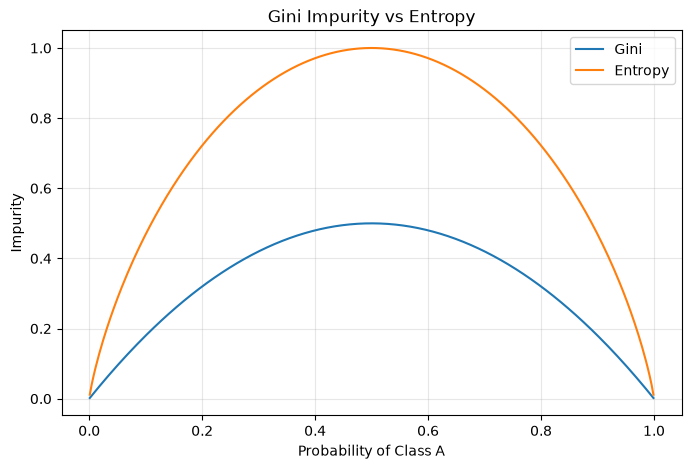

In [24]:
# Compare Gini and entropy across class proportions

p = np.linspace(0.001, 0.999, 300)
gini_values = 1 - (p**2 + (1-p)**2)
entropy_values = -(p*np.log2(p) + (1-p)*np.log2(1-p))

plt.figure(figsize=(8, 5))
plt.plot(p, gini_values, label="Gini")
plt.plot(p, entropy_values, label="Entropy")
plt.xlabel("Probability of Class A")
plt.ylabel("Impurity")
plt.title("Gini Impurity vs Entropy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Train a Decision Tree Classifier

We will use the Iris dataset.

A Decision Tree can learn nonlinear decision boundaries and does not require feature scaling.

In [25]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

tree_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=RANDOM_STATE
)

tree_clf.fit(X_train, y_train)

y_pred = tree_clf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Depth:", tree_clf.get_depth())
print("Leaves:", tree_clf.get_n_leaves())

Test accuracy: 0.8947368421052632
Depth: 3
Leaves: 5


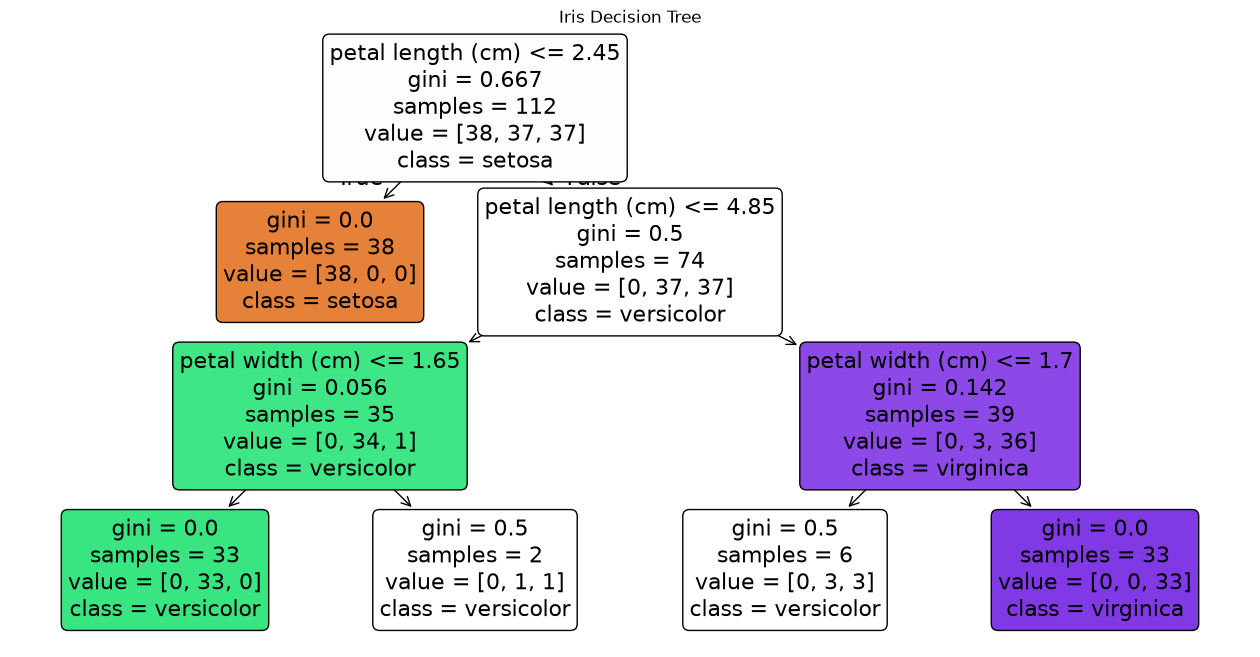

In [26]:
# Visualize the learned tree

plt.figure(figsize=(16, 8))
plot_tree(
    tree_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Iris Decision Tree")
plt.show()

## 6. Reading a Tree

At each internal node you will see:

- feature and threshold
- impurity
- number of samples
- class distribution
- predicted class

A sample follows the left/right branch according to the threshold until it reaches a leaf.

The prediction at a classification leaf is based on the class distribution of training samples in that leaf.

In [27]:
# Prediction probabilities
sample = X_test[:3]

print("Predicted classes:")
print(tree_clf.predict(sample))

print("\nPredicted probabilities:")
print(tree_clf.predict_proba(sample))

Predicted classes:
[0 1 1]

Predicted probabilities:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


## 7. Regularization

An unrestricted tree can grow very deep and overfit.

Important hyperparameters:

| Parameter | Purpose |
|---|---|
| `max_depth` | Maximum depth |
| `min_samples_split` | Minimum samples needed to split an internal node |
| `min_samples_leaf` | Minimum samples allowed in each leaf |
| `max_leaf_nodes` | Maximum number of leaves |
| `min_impurity_decrease` | Required impurity reduction before splitting |
| `ccp_alpha` | Cost-complexity pruning parameter |

The goal is to control complexity so the tree generalizes better.

In [28]:
# Demonstrate the effect of max_depth on the same dataset

depths = [1, 2, 3, 4, 5, 8, None]
results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    results.append({
        "max_depth": depth,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test),
        "tree_depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

depth_results = pd.DataFrame(results)
depth_results

,max_depth,train_accuracy,test_accuracy,tree_depth,leaves
0,1.0,0.669643,0.657895,1,2
1,2.0,0.964286,0.921053,2,3
2,3.0,0.964286,0.894737,3,5
3,4.0,0.991071,0.921053,4,7
4,5.0,0.991071,0.894737,5,8
5,8.0,1.000000,0.894737,6,9
6,NaN,1.000000,0.894737,6,9


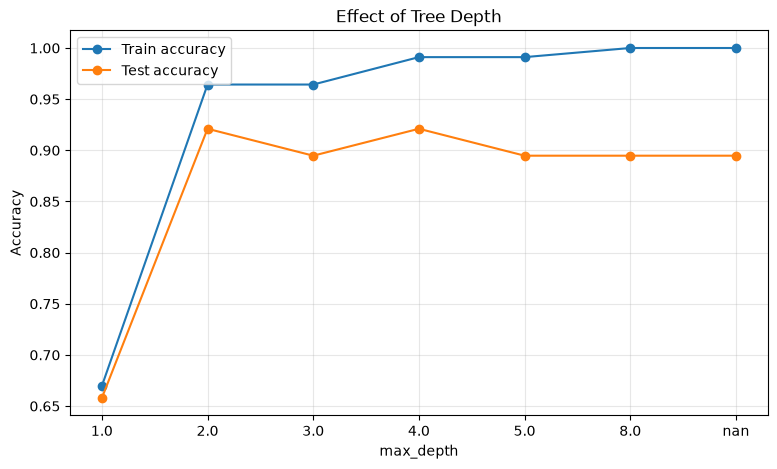

In [29]:
# Plot train vs test accuracy

plt.figure(figsize=(9, 5))
x = np.arange(len(depth_results))
plt.plot(x, depth_results["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(x, depth_results["test_accuracy"], marker="o", label="Test accuracy")
plt.xticks(x, depth_results["max_depth"].astype(str))
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Overfitting with a Nonlinear Dataset

The two-moons dataset makes the effect of tree complexity easier to see.

We will compare a shallow tree with an unrestricted tree.

In [30]:
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=RANDOM_STATE
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_moons
)

models = {
    "Shallow tree": DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    "Moderate tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Unrestricted tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train_m, y_train_m)
    print(
        f"{name:20s} | "
        f"train={model.score(X_train_m, y_train_m):.3f} | "
        f"test={model.score(X_test_m, y_test_m):.3f} | "
        f"depth={model.get_depth()} | "
        f"leaves={model.get_n_leaves()}"
    )

Shallow tree         | train=0.911 | test=0.893 | depth=2 | leaves=4
Moderate tree        | train=0.974 | test=0.947 | depth=5 | leaves=10
Unrestricted tree    | train=1.000 | test=0.947 | depth=8 | leaves=22


## 9. `min_samples_leaf` and `min_samples_split`

These parameters are especially useful when a tree is making very small branches.

Example:

```python
DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5
)
```

Interpretation:

- A node needs enough samples before it can split.
- Every final leaf must contain at least the configured number of samples.

Larger values generally make the model smoother/simpler.

In [31]:
regularized_models = {
    "Baseline": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "min_leaf=5": DecisionTreeClassifier(min_samples_leaf=5, random_state=RANDOM_STATE),
    "min_leaf=10": DecisionTreeClassifier(min_samples_leaf=10, random_state=RANDOM_STATE),
    "depth=4": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
}

for name, model in regularized_models.items():
    model.fit(X_train_m, y_train_m)
    print(
        f"{name:15s} | "
        f"train={model.score(X_train_m, y_train_m):.3f} | "
        f"test={model.score(X_test_m, y_test_m):.3f} | "
        f"depth={model.get_depth()} | "
        f"leaves={model.get_n_leaves()}"
    )

Baseline        | train=1.000 | test=0.947 | depth=8 | leaves=22
min_leaf=5      | train=0.980 | test=0.947 | depth=7 | leaves=15
min_leaf=10     | train=0.974 | test=0.947 | depth=6 | leaves=13
depth=4         | train=0.911 | test=0.893 | depth=4 | leaves=8


## 10. Decision Tree Regression

A `DecisionTreeRegressor` predicts continuous values.

With the default `squared_error` criterion, splits are selected using squared-error reduction / variance reduction. The prediction in a terminal node is the mean target value for that leaf.

In [32]:
# Create a nonlinear regression dataset
rng = np.random.RandomState(RANDOM_STATE)

X_reg = np.sort(6 * rng.rand(120, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + 0.15 * rng.randn(120)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE
)

reg_shallow = DecisionTreeRegressor(
    max_depth=2,
    random_state=RANDOM_STATE
)

reg_deep = DecisionTreeRegressor(
    max_depth=6,
    random_state=RANDOM_STATE
)

reg_shallow.fit(X_train_r, y_train_r)
reg_deep.fit(X_train_r, y_train_r)

print("Shallow R²:", reg_shallow.score(X_test_r, y_test_r))
print("Deep R²:", reg_deep.score(X_test_r, y_test_r))

Shallow R²: 0.8627135373914703
Deep R²: 0.9136903043756887


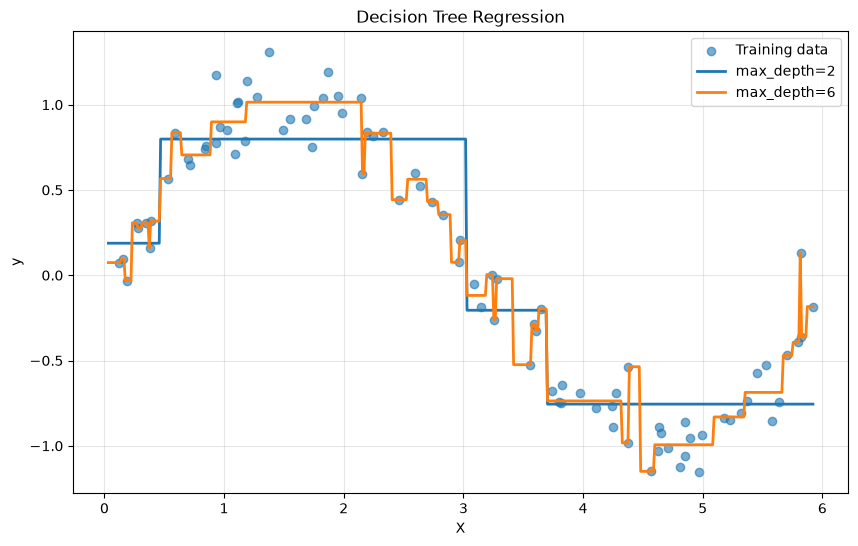

In [33]:
# Visualize regression tree predictions

X_plot = np.linspace(X_reg.min(), X_reg.max(), 500).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_r, y_train_r, label="Training data", alpha=0.6)
plt.plot(
    X_plot,
    reg_shallow.predict(X_plot),
    linewidth=2,
    label="max_depth=2"
)
plt.plot(
    X_plot,
    reg_deep.predict(X_plot),
    linewidth=2,
    label="max_depth=6"
)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Decision Tree Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Regression Error Comparison

Let's compare several tree depths using MSE and R².

In [34]:
depths = [1, 2, 3, 4, 6, 10, None]
reg_results = []

for depth in depths:
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_r, y_train_r)

    train_pred = model.predict(X_train_r)
    test_pred = model.predict(X_test_r)

    reg_results.append({
        "max_depth": depth,
        "train_MSE": mean_squared_error(y_train_r, train_pred),
        "test_MSE": mean_squared_error(y_test_r, test_pred),
        "train_R2": r2_score(y_train_r, train_pred),
        "test_R2": r2_score(y_test_r, test_pred),
        "leaves": model.get_n_leaves()
    })

reg_results = pd.DataFrame(reg_results)
reg_results

,max_depth,train_MSE,test_MSE,train_R2,test_R2,leaves
0,1.0,0.113695,0.168763,0.796655,0.654373,2
1,2.0,0.062230,0.067034,0.888701,0.862714,4
2,3.0,0.026682,0.046360,0.952279,0.905055,8
3,4.0,0.018210,0.036486,0.967430,0.925277,16
4,6.0,0.007196,0.042143,0.987129,0.913690,41
5,10.0,0.000120,0.049224,0.999786,0.899190,86
6,NaN,0.000000,0.050289,1.000000,0.897008,90


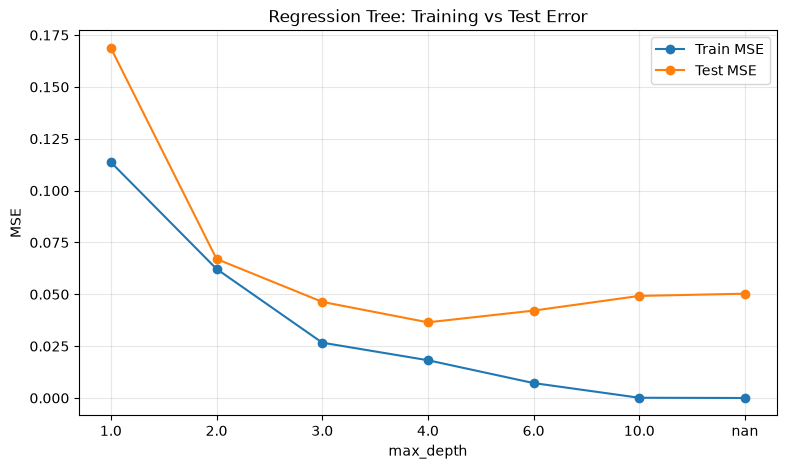

In [35]:
plt.figure(figsize=(9, 5))
x = np.arange(len(reg_results))
plt.plot(x, reg_results["train_MSE"], marker="o", label="Train MSE")
plt.plot(x, reg_results["test_MSE"], marker="o", label="Test MSE")
plt.xticks(x, reg_results["max_depth"].astype(str))
plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Regression Tree: Training vs Test Error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Tree Instability

Decision trees can have high variance.

A small change in the training data can change the best split near the root. Once the root changes, the downstream branches can change as well.

This is one reason ensembles such as Random Forests are useful: combining many trees can reduce the variance of an individual unstable tree.

In [36]:
# A simple instability experiment:
# Train trees after removing a small number of training samples.

X_a, X_b = X_train_m[:-5], X_train_m[5:]
y_a, y_b = y_train_m[:-5], y_train_m[5:]

tree_a = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree_b = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)

tree_a.fit(X_a, y_a)
tree_b.fit(X_b, y_b)

print("Tree A depth:", tree_a.get_depth())
print("Tree B depth:", tree_b.get_depth())
print("Tree A leaves:", tree_a.get_n_leaves())
print("Tree B leaves:", tree_b.get_n_leaves())

Tree A depth: 5
Tree B depth: 5
Tree A leaves: 10
Tree B leaves: 10


## 13. Feature Importance

Decision trees expose `feature_importances_`.

These values indicate how much each feature contributed to impurity reduction in the fitted tree.

Important caution: feature importance is not automatically proof of causation or a complete measure of feature usefulness.

In [37]:
importance = pd.Series(
    tree_clf.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=False)

importance

petal length (cm)    0.950732
petal width (cm)     0.049268
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64

## 14. Cost-Complexity Pruning

Another important regularization technique is **Minimal Cost-Complexity Pruning**.

In scikit-learn, the `ccp_alpha` parameter controls pruning.

A larger `ccp_alpha` generally favors a simpler subtree.

You can inspect possible pruning values using:

```python
path = model.cost_complexity_pruning_path(X_train, y_train)
```

This is useful when selecting a tree size using validation data.

In [38]:
# Inspect a pruning path
pruning_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
pruning_tree.fit(X_train_m, y_train_m)

path = pruning_tree.cost_complexity_pruning_path(X_train_m, y_train_m)

print("Number of candidate alpha values:", len(path.ccp_alphas))
print("First few alphas:", path.ccp_alphas[:10])

Number of candidate alpha values: 12
First few alphas: [0.         0.0025974  0.0026455  0.00276786 0.00380952 0.00520022
 0.01088435 0.01581713 0.02244625 0.04562197]


## 15. Strengths and Weaknesses

### Strengths

- Easy to understand and visualize
- Handles nonlinear relationships
- Captures feature interactions
- Usually does not require feature scaling
- Works for classification and regression
- Prediction is fast

### Weaknesses

- Can overfit easily
- High variance / instability
- Deep trees can become very large
- Basic trees create axis-aligned splits
- Regression trees do not naturally extrapolate well

**Key idea:** a single decision tree is flexible but unstable. Regularization and ensembles are important tools for improving generalization.

# Exercises

## Exercise 2 — Gini and Entropy

For a node containing:

```text
Class A = 70
Class B = 30
```

Calculate:

1. Gini impurity
2. Entropy

Then compare them with a 50/50 node.

---

## Exercise 3 — Classification Tree

Using Iris:

1. Train a tree with `max_depth=2`.
2. Train another with `max_depth=5`.
3. Train an unrestricted tree.
4. Compare train/test accuracy.
5. Compare depth and number of leaves.

---

## Exercise 4 — Regularization

Using the two-moons dataset, compare:

```python
min_samples_leaf=1
min_samples_leaf=5
min_samples_leaf=10
min_samples_leaf=20
```

Which setting generalizes best?

---

## Exercise 5 — Regression

Train:

```python
DecisionTreeRegressor(max_depth=2)
DecisionTreeRegressor(max_depth=4)
DecisionTreeRegressor(max_depth=8)
DecisionTreeRegressor(max_depth=None)
```

Compare train/test MSE and R².

---

## Exercise 6 — Explain in your own words

Write 2–3 sentences answering each:

1. What is CART?
2. What is Gini impurity?
3. What is entropy?
4. Why does a deep tree overfit?
5. What does `min_samples_leaf` do?
6. Why are decision trees unstable?
7. Why don't decision trees normally require feature scaling?
8. How does a regression tree make a prediction?
9. Why can Random Forests improve over a single decision tree?
10. What is the difference between classification and regression tree objectives?

# Day 31 — Final Review

### Remember these 7 points

1. **CART** recursively searches for useful binary splits.
2. **Gini** and **entropy** measure classification impurity.
3. **Lower impurity** means a more homogeneous node.
4. **Regularization** controls tree complexity.
5. **Regression trees** generally minimize squared error and predict the mean target in each leaf.
6. **Deep unrestricted trees** can memorize training data.
7. **Tree instability** is a major reason ensemble methods such as Random Forests are powerful.

### Quick self-test

Without looking above, explain:

> "How does a decision tree go from raw training data to a prediction?"

If you can clearly explain **split → impurity/error → recursion → leaf prediction → regularization**, you understand the core of Day 31.